Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

# pai
seed = 42
model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(15, 32, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading LLava


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:09<00:00,  4.68s/it]
Some parameters are on the meta device because they were offloaded to the cpu.


In [4]:
# image_id = 226988
# image_id = 46011
image_id = 337443
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")

template = INSTRUCTION_TEMPLATE[model]
query = "Please help me describe the image in detail."

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path)

In [5]:
print(questions)

A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. USER: <image>
Please help me describe the image in detail. ASSISTANT:


In [6]:
# baseline
# with torch.inference_mode():
#     outputs = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         # min_new_tokens=60,
#         use_cache=True,
#         **kwargs,
#     )

# output_baseline = model_loader.decode(outputs)[0]

In [7]:
use_jsd=1
alpha = 2
beta = 0

with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        use_jsd=1,
        alpha = alpha,
        beta = beta,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

OutOfMemoryError: CUDA out of memory. Tried to allocate 86.00 MiB (GPU 0; 44.52 GiB total capacity; 6.95 GiB already allocated; 82.88 MiB free; 7.12 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

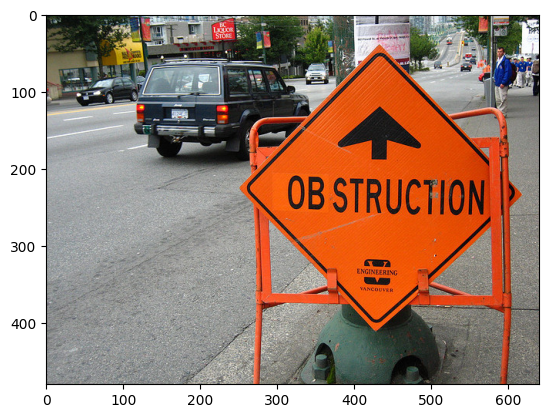

Ours:
 The scene depicts a busy street with several cars and trucks driving by. There are at least five cars and two trucks visible in the image, one of which is positioned behind a sign warning about obstructed construction. The sign is placed on the sidewalk next to the roadway, alerting drivers to the potential obstruction ahead.

In addition to the vehicles, there are two people visible in the scene, one near the left side of the image and another person towards the right side. They seem to be pedestrians or drivers observing their surroundings.


In [ ]:
plt.imshow(image)
plt.show()
# print("Baseline\n", output_baseline)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [ ]:
evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
cap_dict = evaluator.compute_sample_chair(outputs, image_id)
print(cap_dict)

{'image_id': 337443, 'caption': 'The scene depicts a busy street with several cars and trucks driving by. There are at least five cars and two trucks visible in the image, one of which is positioned behind a sign warning about obstructed construction. The sign is placed on the sidewalk next to the roadway, alerting drivers to the potential obstruction ahead.\n\nIn addition to the vehicles, there are two people visible in the scene, one near the left side of the image and another person towards the right side. They seem to be pedestrians or drivers observing their surroundings.', 'mscoco_hallucinated_words': [], 'mscoco_gt_words': ['car', 'person', 'orange', 'backpack', 'truck'], 'mscoco_generated_words': ['car', 'truck', 'car', 'truck', 'person', 'person', 'person', 'person'], 'hallucination_idxs': [], 'metrics': {'CHAIRs': 0, 'CHAIRi': 0.0, 'Recall': 0.6, 'Len': 103}}


In [44]:
tokenizer = model_loader.tokenizer
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0
start_idx = 85
outputs_tokens = output_ids[0, input_token_len:]
words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
print(words)

 lights can be seen at various points along the street, ensuring smooth traffic flow.\n\nOverall, the scene captures a typical urban environment with construction work underway, and people going about their daily activities.</s>


In [50]:
# token_idx = -68
# token_idx = -63
# token_idx = -42
token_idx = 85
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [57]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

top_k_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("final_tokens\n", final_words)
print(final_tokens_probs)

top_k_candidate_tokens
 ['lights', 'appears', 'signals', 'is', 'signs', 'seems', 'light', 'con', 'and', 'can']
tensor([0.9546, 0.0097, 0.0068, 0.0061, 0.0049, 0.0040, 0.0030, 0.0014, 0.0012,
        0.0010], device='cuda:0', dtype=torch.float16, grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 ['lights']
tensor([0.9546], device='cuda:0', dtype=torch.float16,
       grad_fn=<SliceBackward0>)
final_tokens
 ['lights', '<s>', '<0x00>', '<0x03>', '<0x04>', '<unk>', '</s>', '<0x02>', '<0x05>', '<0x01>']
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')


In [52]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

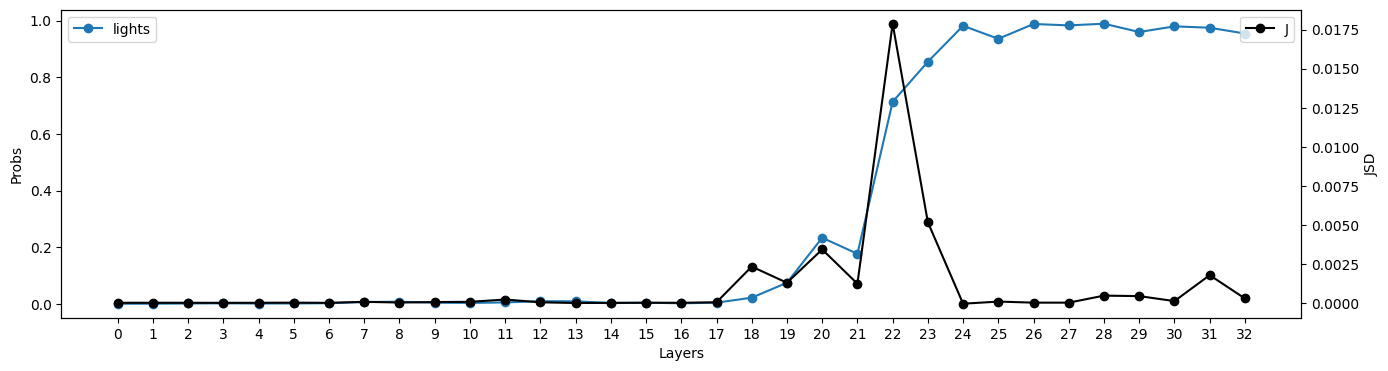

Max JS divergence idx:  22


In [53]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()
print("Max JS divergence idx: ", jsd.argmax().item())

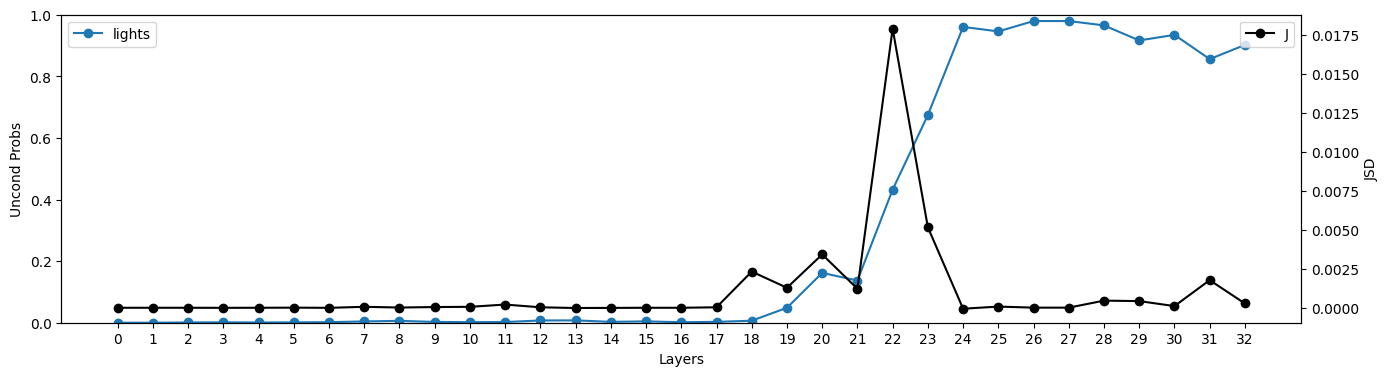

In [54]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()